In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df=sns.load_dataset('titanic')

In [53]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [62]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [55]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [56]:

df['age']=df['age'].fillna(df['age'].median())

df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])



In [57]:
df.drop(columns=['deck','embark_town'],inplace=True)

In [58]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(116)

In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    775 non-null    int64   
 1   pclass      775 non-null    int64   
 2   sex         775 non-null    str     
 3   age         775 non-null    float64 
 4   sibsp       775 non-null    int64   
 5   parch       775 non-null    int64   
 6   fare        775 non-null    float64 
 7   embarked    775 non-null    str     
 8   class       775 non-null    category
 9   who         775 non-null    str     
 10  adult_male  775 non-null    bool    
 11  alive       775 non-null    str     
 12  alone       775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 69.0 KB


In [64]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


**EDA**

In [65]:
df.shape

(775, 13)

In [67]:
cat_col=df.select_dtypes(include='object').columns

/tmp/ipykernel_23944/1176977036.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=df.select_dtypes(include='object').columns


In [68]:
cat_col

Index(['sex', 'embarked', 'who', 'alive'], dtype='str')

In [70]:
df['sex'].value_counts()

sex
male      483
female    292
Name: count, dtype: int64

In [71]:
df['embarked'].value_counts()

embarked
S    562
C    155
Q     58
Name: count, dtype: int64

In [72]:
df['who'].value_counts()

who
man      443
woman    250
child     82
Name: count, dtype: int64

In [73]:
df['alive'].value_counts()

alive
no     455
yes    320
Name: count, dtype: int64

In [ ]:
df['survived'].value_counts()

In [74]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'alive', 'alone'],
      dtype='str')

In [76]:
df=df.drop(['class','who','alive','alone','adult_male'],axis=1)

In [77]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [91]:
df['fare']=df['fare']*100

In [92]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,725.00,S
1,1,1,female,38.0,1,0,7128.33,C
2,1,3,female,26.0,0,0,792.50,S
3,1,1,female,35.0,1,0,5310.00,S
4,0,3,male,35.0,0,0,805.00,S


In [ ]:
df['parch'].value_counts()

parch
0    571
1    114
2     75
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [97]:
df['sibsp'].value_counts()

sibsp
0    508
1    201
2     27
4     18
3     14
5      5
8      2
Name: count, dtype: int64

In [95]:
df['survived'].value_counts()

survived
0    455
1    320
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of the Survival')

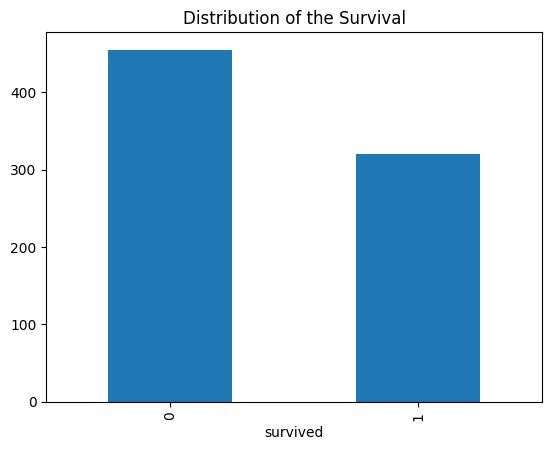

In [79]:
df['survived'].value_counts().plot(
 kind='bar'
)
plt.title("Distribution of the Survival")

Text(0.5, 1.0, 'Distribution of the Survival')

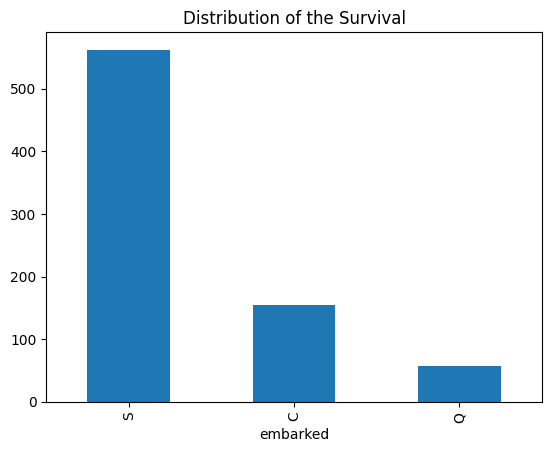

In [115]:
df['embarked'].value_counts().plot(
 kind='bar'
)
plt.title("Distribution of the Survival")

Text(0.5, 1.0, 'Distribution of the AGE')

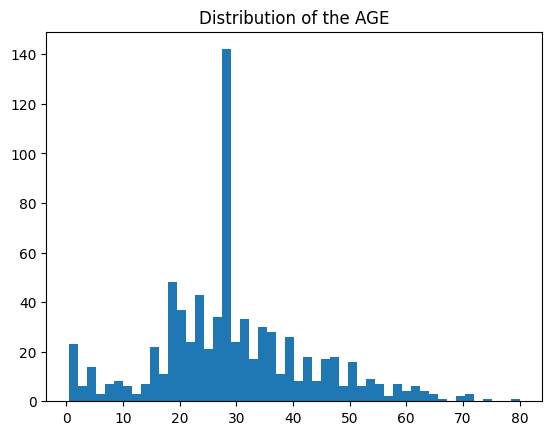

In [89]:
plt.hist(df['age'],bins=50)
plt.title("Distribution of the AGE")

Text(0.5, 1.0, 'Distribution of the passanger class')

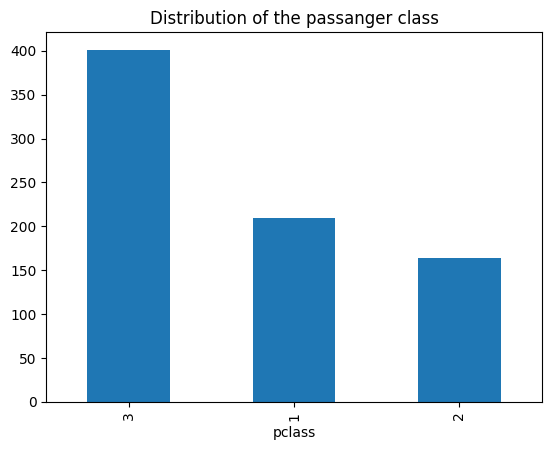

In [85]:
df['pclass'].value_counts().plot(
 kind='bar'
)
plt.title("Distribution of the passanger class")

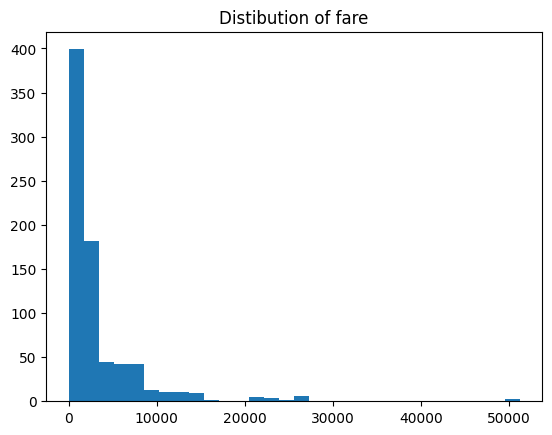

In [94]:
plt.hist(df['fare'],bins=30)
plt.title("Distibution of fare")
plt.show()

**Feature Enginerring**

In [99]:
## Create a new feature family Size

df['family_size']=df['sibsp']+df['parch']+1

In [100]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size
0,0,3,male,22.0,1,0,725.00,S,2
1,1,1,female,38.0,1,0,7128.33,C,2
2,1,3,female,26.0,0,0,792.50,S,1
3,1,1,female,35.0,1,0,5310.00,S,2
4,0,3,male,35.0,0,0,805.00,S,1


In [103]:
df=df.drop(['sibsp','parch'],axis=1)

In [105]:
df.head()

,survived,pclass,sex,age,fare,embarked,family_size
0,0,3,male,22.0,725.00,S,2
1,1,1,female,38.0,7128.33,C,2
2,1,3,female,26.0,792.50,S,1
3,1,1,female,35.0,5310.00,S,2
4,0,3,male,35.0,805.00,S,1


In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     775 non-null    int64  
 1   pclass       775 non-null    int64  
 2   sex          775 non-null    str    
 3   age          775 non-null    float64
 4   fare         775 non-null    float64
 5   embarked     775 non-null    str    
 6   family_size  775 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 48.4 KB


In [108]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

label=LabelEncoder()
df['sex']=label.fit_transform(df['sex'])

In [109]:
df.head()

,survived,pclass,sex,age,fare,embarked,family_size
0,0,3,1,22.0,725.00,S,2
1,1,1,0,38.0,7128.33,C,2
2,1,3,0,26.0,792.50,S,1
3,1,1,0,35.0,5310.00,S,2
4,0,3,1,35.0,805.00,S,1


In [112]:
ohe=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
emb_encd=ohe.fit_transform(df[['embarked']])

In [114]:
emb_encd

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(775, 3))

In [116]:
emb_df=pd.DataFrame(emb_encd,columns=ohe.get_feature_names_out(['embarked']))

In [117]:
df=pd.concat((df,emb_df),axis=1)

In [118]:
df.head()

,survived,pclass,sex,age,fare,embarked,family_size,embarked_C,embarked_Q,embarked_S
0,0.0,3.0,1.0,22.0,725.00,S,2.0,0.0,0.0,1.0
1,1.0,1.0,0.0,38.0,7128.33,C,2.0,1.0,0.0,0.0
2,1.0,3.0,0.0,26.0,792.50,S,1.0,0.0,0.0,1.0
3,1.0,1.0,0.0,35.0,5310.00,S,2.0,0.0,0.0,1.0
4,0.0,3.0,1.0,35.0,805.00,S,1.0,0.0,0.0,1.0


In [119]:
df=df.drop(['embarked'],axis=1)

In [120]:
df.head()

,survived,pclass,sex,age,fare,family_size,embarked_C,embarked_Q,embarked_S
0,0.0,3.0,1.0,22.0,725.00,2.0,0.0,0.0,1.0
1,1.0,1.0,0.0,38.0,7128.33,2.0,1.0,0.0,0.0
2,1.0,3.0,0.0,26.0,792.50,1.0,0.0,0.0,1.0
3,1.0,1.0,0.0,35.0,5310.00,2.0,0.0,0.0,1.0
4,0.0,3.0,1.0,35.0,805.00,1.0,0.0,0.0,1.0


In [121]:
df.to_csv("Preprocessed_titanic.csv",index=False)